In [ ]:
# 아이스크림 판매 예측 - data set만들기

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 시드 고정
np.random.seed(42)

# 기간 : 2019년 1월 ~ 2023년 12월
dates = pd.date_range(start="2019-01-01", end="2023-12-01", freq="MS")
n = len(dates)

# 1. 평균 기온 (여름에 높고, 겨울에 낮은 계절성 반영)
temperature = 15 + 10 * np.sin(2 * np.pi * np.arange(n)/12) + np.random.normal(0, 1, n)

# 2. 휴일 수 (임의 설정 : 평균 4일, 2 ~ 6일 사이 랜덤)
holidays = np.random.randint(2, 7, n)

# 3. 프로모션 여부 (30% 확률로 있음)
promotion = np.random.choice([0, 1], size=n, p=[0.7, 0.3])

# 4. 판매량(타겟) - 기온, 휴일, 프로모션의 영향을 받는 함수 + 노이즈
# 기본 트렌드 : 연간 5씩 증가하는 우상향
base = 100 + np.linspace(0, 30, n)

# 5. 영향 계수 : 기온(2.5), 휴일(3), 프로모션(15)
sales = base + (temperature * 2.5) + (holidays * 3) + (promotion * 15) + np.random.normal(0, 10, n)
sales = np.round(sales, 0)

# 데이터프레임 생성
df = pd.DataFrame({
    'Month' : dates,
    'Temperature' : np.round(temperature, 1),
    'Holidays' : holidays,
    'Promotion' : promotion,
    'Sales' : sales
})

# CSV파일로 저장
df.to_csv('ice_cream_sales_data.csv', index=False, encoding='utf-8-sig')
print(df.head())

# 시각화
plt.figure(figsize=(12, 5))
plt.plot(df['Month'], df['Sales'], label='Sales', linewidth=2)
plt.plot(df['Month'], df['Temperature'], label='Temperature', linestyle='--')
plt.plot(df['Month'], df['Promotion'], label='Promotion(x50)')
plt.title("Ice Cream Sales with External Features(Synthetic)")
plt.xlabel("Month")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

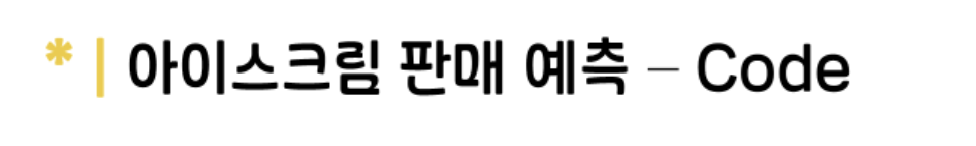

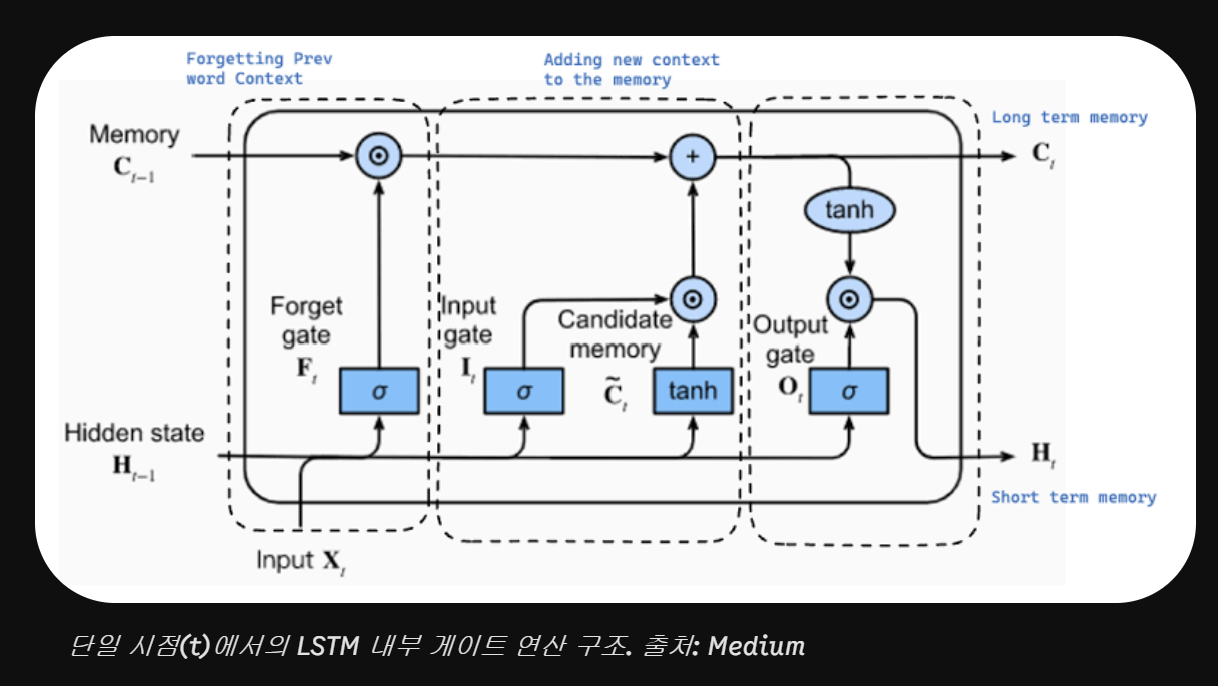

In [ ]:
# LSTM : 과거 데이터의 흐름(시간 순서)을 기억한다
# DNN은 12달치 데이터(각 달마다 피처 3개)를 입력하려면, 
# 12 * 3 = 36형태로, 데이터를 일렬로 평평하게 펼쳐서(Flatten) 한번에 입력해야 한다
# LSTM
# [기온, 휴일, 프로모션] -> X0으로 입력, h0(단기 상태), c0(장기 상태)
# x0 : 현재 데이터, h(t-1), c(t-1) : 이전 상태를 어떻게 결합할지 결정하기 위해 3개의 게이트 연산을 수행한다.

In [ ]:
# Forget Gate(망각 게이트) : 이전 장기 상태 c(t-1)중 무엇을 삭제할지 결정한다
# Input Gate(입력 게이트) : 현재 시점의 새로운 데이터(X(t)) 중, 무엇을 장기 상태(c(t))에 추가할지 결정한다
# Cell State Update(셀 상태 갱신) : 과거 장기 상태 c(t-1)에 Forget Gate연산을 곱해 불필요한 데이터를 지우고, Input Gate에서 계산된 새로운 데이터
# 를 더한다
# 새로 완성된 장기상태 c(t)를 바탕으로, 다음 시점으로 넘기거나 최종 출력으로 사용할 단기 상태 h(t)를 생성한다

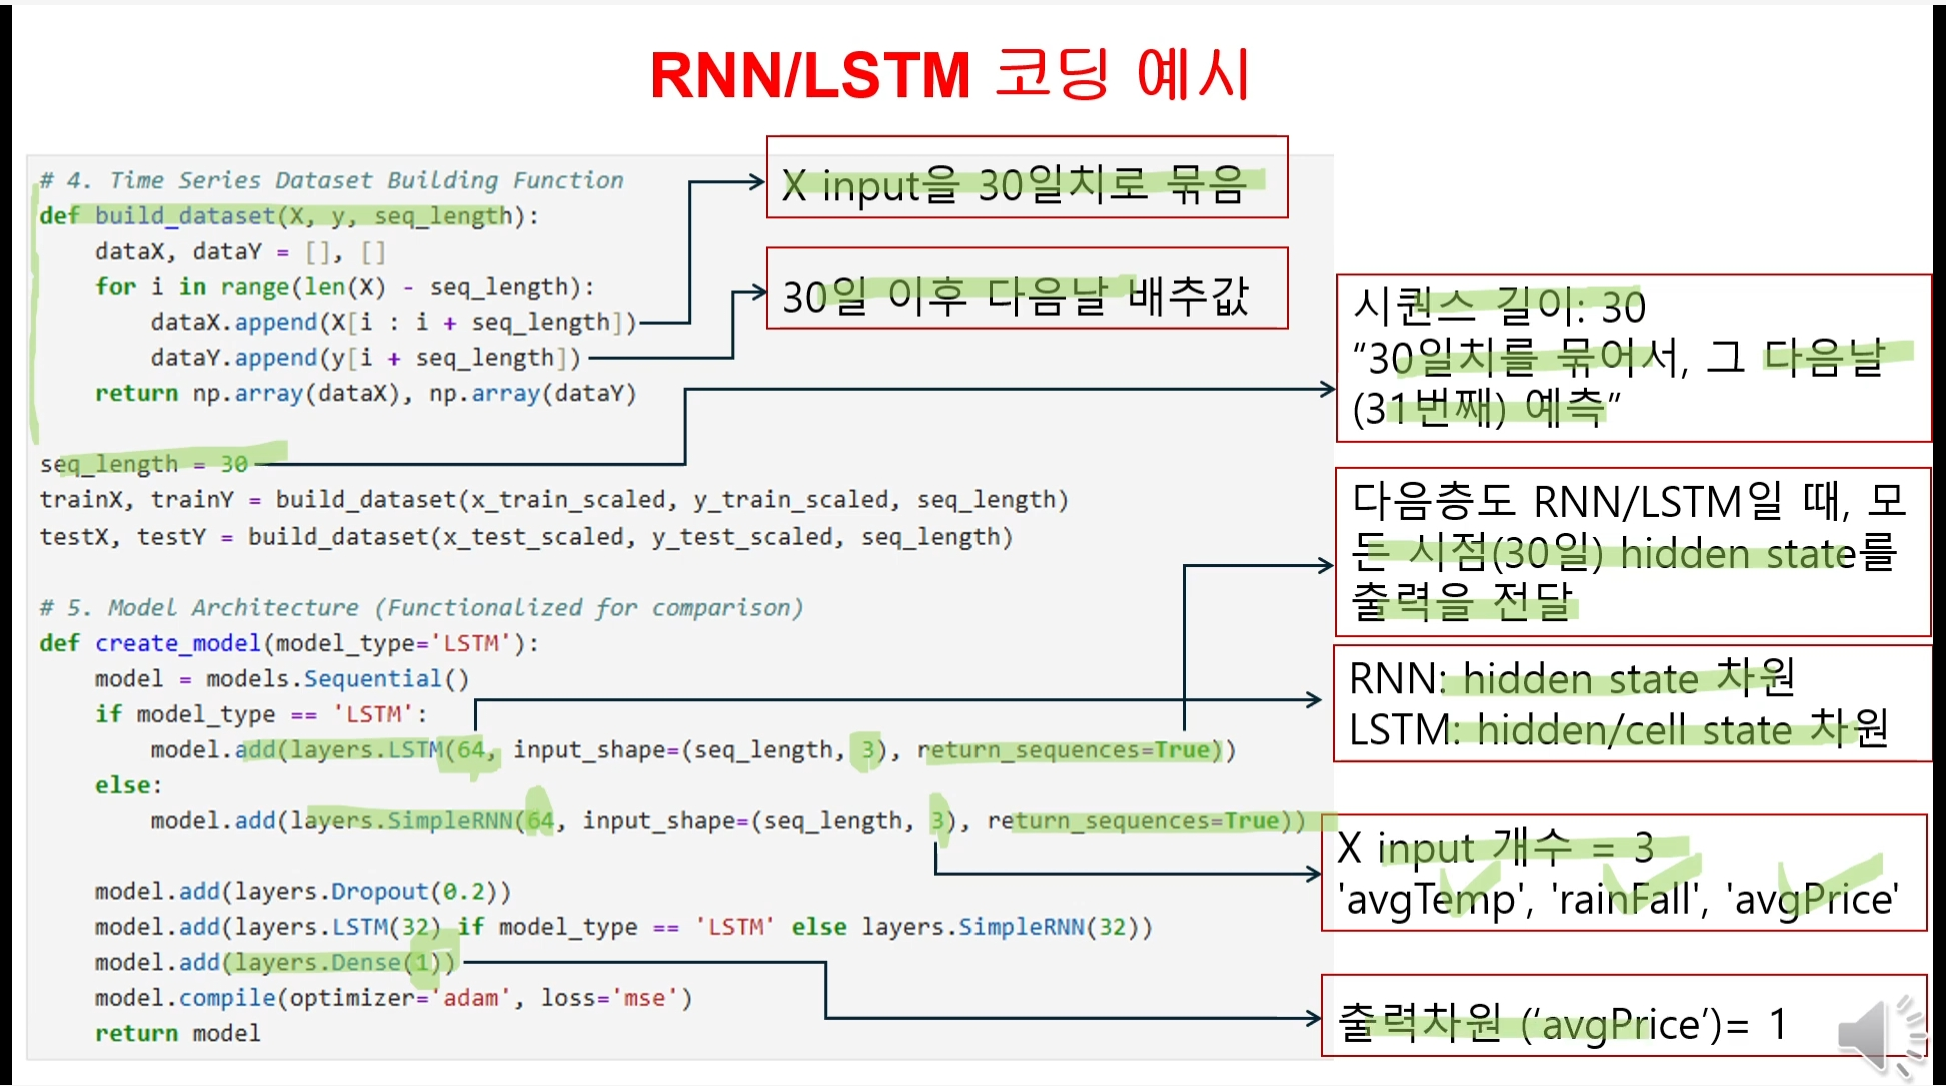

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. 데이터 불러오기
df = pd.read_csv("ice_cream_sales_data.csv", parse_dates=['Month'])
print(df.head())

# 2. feature, target설정
features = ['Temperature', 'Holidays', 'Promotion']
target = 'Sales'

# 3. 정규화
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])
# print(X_scaled)
# print(y_scaled)

# 4. 시퀀스 생성 함수(ex : 12개월 -> 다음 달 예측)
def create_sequences(X, y, time_steps=12):
    Xs, ys = [], []

    # len(X) : 60, time_steps : 12
    # 인덱스를 한칸씩 옆으로 넘기면서 +1 했을 때
    # 47번째 + 12 = 59까지만
    # 60부터는 없음
    for i in range(len(X)-time_steps): 
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled) # X_seq : (48, 12, 3), y_seq : (48, 1)

# 5. 학습/테스트 분리(8 : 2)
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# 6. LSTM 모델 정의
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_seq.shape[1], X_seq.shape[2])), #(12, 3)
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# 7. 학습
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_split=0.1, verbose=1)

# 8. 예측
y_pred = model.predict(X_test)
y_pred_inv = scaler_y.inverse_transform(y_pred) #역정규화 : 원래 단위로 변경
y_test_inv = scaler_y.inverse_transform(y_test)

# 9. 시각화
plt.figure(figsize=(12, 5))
plt.plot(range(len(y_test_inv)), y_test_inv, label='Actual Sales', marker = 'o')
plt.plot(range(len(y_pred_inv)), y_pred_inv, label='Predicted Sales', marker = 'x')
plt.title("LSTM Sales Prediction vs Actual")
plt.xlabel("Test Time Index")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. 마지막 12개월을 기반으로 한 다음 예측
last_seq = X_scaled[-12:].reshape(1, 12, len(features)) # (갯수, 12개월, features)
next_pred_scaled = model.predict(last_seq)
next_pred = scaler_y.inverse_transform(next_pred_scaled)
print(f"다음 달 예상 판매량 : {next_pred[0][0]:.2f}")

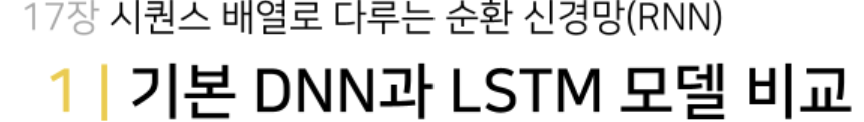

In [ ]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, LSTM
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

# 데이터셋 로드
newsgroups_data = fetch_20newsgroups(subset='all')
texts = newsgroups_data.data
labels = newsgroups_data.target
# print("texts", len(texts))
# print("target", labels.shape)

# 데이터 전처리
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index

# 하이퍼 파라미터 설정
max_len = 1000
data = pad_sequences(sequences, maxlen=max_len)
labels = LabelBinarizer().fit_transform(labels)

# 훈련 및 테스트 분할
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=0)

# DNN
model_dnn = Sequential()
model_dnn.add(Embedding(20000, 128, input_shape=(max_len,)))
model_dnn.add(Flatten())
model_dnn.add(Dense(256, activation='relu'))
model_dnn.add(Dense(20, activation='softmax'))
model_dnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 학습
model_dnn.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_test, y_test))

# LSTM
model_lstm = Sequential()
model_lstm.add(Embedding(20000, 128, input_shape=(max_len,)))
model_lstm.add(LSTM(128))
model_lstm.add(Dense(20, activation='softmax'))
model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 학습
model_lstm.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_test, y_test))

# DNN 모델 평가
dnn_loss, dnn_accuracy = model_dnn.evaluate(x_test, y_test)
print(f"DNN 모델 정확도 : {dnn_accuracy:.4f}")

# LSTM 모델 평가
lstm_loss, lstm_accuracy = model_lstm.evaluate(x_test, y_test)
print(f"LSTM 모델 정확도 : {lstm_accuracy:.4f}")

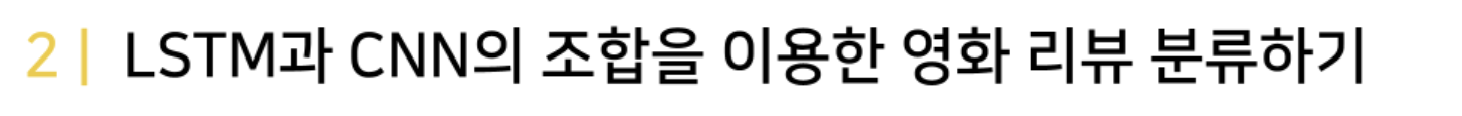

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 200)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 200)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        64,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,393 (8.28 MB)

 Trainable params: 2,171,393 (8.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6976 - loss: 0.5223
Epoch 1: val_loss improved from None to 0.26991, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 126ms/step - accuracy: 0.8060 - loss: 0.3950 - val_accuracy: 0.8873 - val_loss: 0.2699 - learning_rate: 0.0010
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9117 - loss: 0.2315
Epoch 2: val_loss did not improve from 0.26991
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 115ms/step - accuracy: 0.9244 - loss: 0.2020 - val_accuracy: 0.8840 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9428 - loss: 0.1561
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 3: val_loss did not improve from 0.26991
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.9469 - loss: 0.1458 - val_accuracy: 0.8656 - val_loss: 0.3637 - learning_rate: 0.0010
E

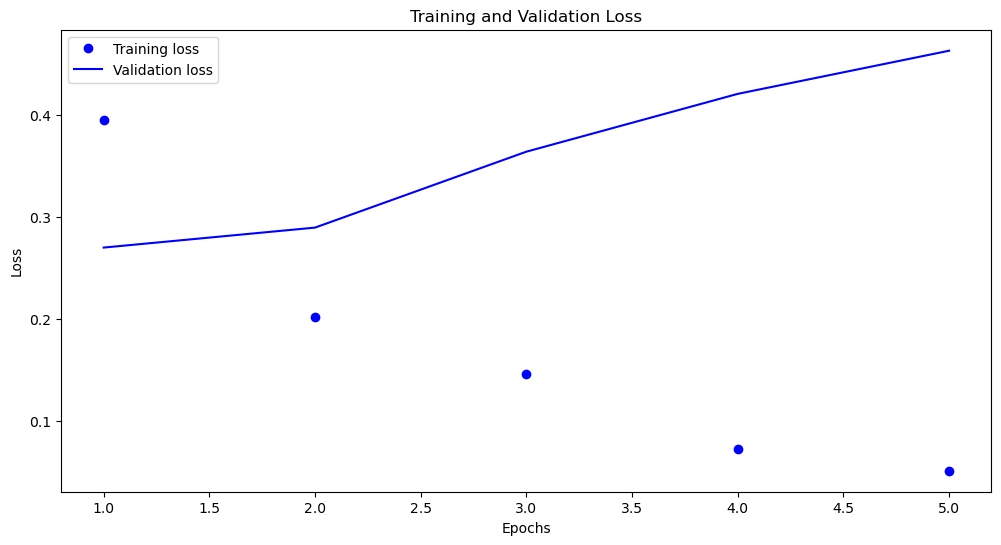

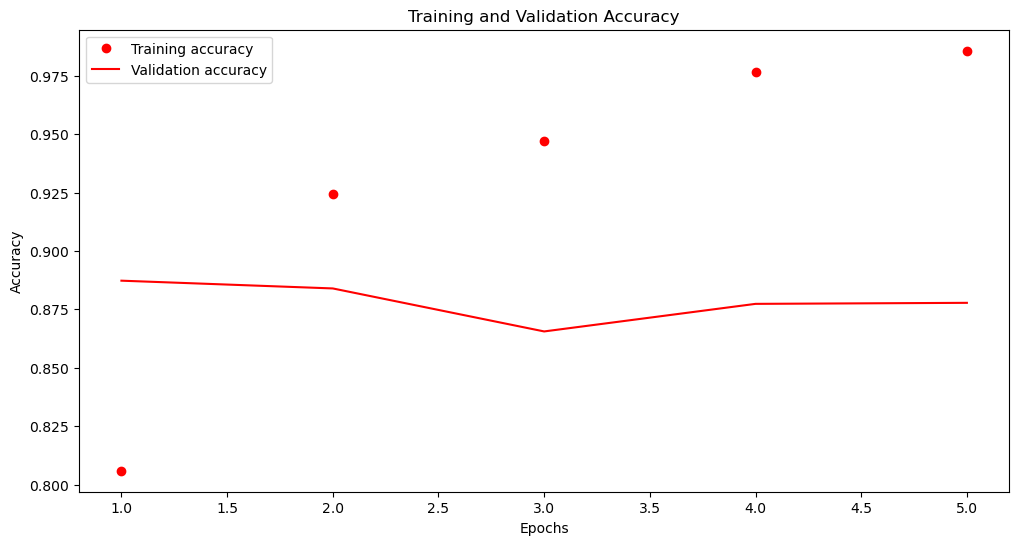

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy
import os

from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.datasets import imdb
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# seed 값 설정
seed = 0
numpy.random.seed(seed)
tf.random.set_seed(0)

# 학습셋, 테스트셋 지정하기
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000) # 숫자 형태로 데이터를 만들어줌(imdb.load_data)

# 데이터 전처리
x_train = sequence.pad_sequences(x_train, maxlen=200)
x_test = sequence.pad_sequences(x_test, maxlen=200)

# 모델의 설정
model = Sequential()
model.add(Embedding(10000, 200))
model.add(Dropout(0.5))
model.add(Conv1D(64, 5, padding='valid', activation='relu', strides=1))
model.add(MaxPooling1D(pool_size=4))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(1, activation='sigmoid'))

# 모델의 요약을 보기 위해, 한번 모델을 호출하여 초기화한다
model.build(input_shape=(None, 100))
model.summary()

# 모델의 컴파일
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=4, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)

model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

# 모델의 실행
history = model.fit(x_train, y_train, batch_size=64, epochs=20, validation_data=(x_test, y_test), 
                    callbacks=[early_stopping, reduce_lr, model_checkpoint])

# 테스트 정확도 출력
print("\n Test Accuracy : %.4f" % (model.evaluate(x_test, y_test)[1]))

# 그래프 그리기
history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

# 손실 그래프
plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 정확도 그래프
plt.figure(figsize=(12, 6))
plt.plot(epochs, accuracy, 'ro', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()